# 1. Preparing

In [3]:
# audio libraries
#!pip uninstall -y torch torchaudio torchvision
!pip install torch torchaudio librosa soundfile matplotlib pesq

!pip install scipy==1.11.4

In [4]:
# system packages for RNNoise
!apt-get update
!apt-get install -y libtool automake autoconf build-essential sox pkg-config libsndfile1 ffmpeg

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
autoconf is already the newest version (2.71-2).
automake is already the newest version (1:1.1

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
clean_path = "/content/drive/MyDrive/cleanSpeech/84-121123-0006.flac"

noise_files = [
"/content/drive/MyDrive/noises/1-21189-A-10.wav",
"/content/drive/MyDrive/noises/1-47709-A-16.wav",
"/content/drive/MyDrive/noises/3-170312-A-31.wav",
"/content/drive/MyDrive/noises/1-19872-B-36.wav",
"/content/drive/MyDrive/noises/2-43806-A-42.wav",
"/content/drive/MyDrive/noises/1-54747-A-46.wav"
]

snr_levels = [0,5,10,20,40]

In [3]:
import torch
import pprint
import torchaudio
import librosa
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import Audio
from scipy.signal import wiener
from pesq import pesq

In [7]:
speech, sr = torchaudio.load(clean_path)

speech = torch.mean(speech, dim=0, keepdim=True)  # mono
speech = speech[0]

# 2 Noise addition

Add noise with SNR

In [8]:
# Function to match noise length
def match_length(signal, target_len):
    if len(signal) < target_len:
        repeat = int(np.ceil(target_len / len(signal)))
        signal = signal.repeat(repeat)
    return signal[:target_len]

def add_noise(clean, noise, snr_db):

    clean_power = torch.mean(clean**2)
    noise_power = torch.mean(noise**2)

    snr = 10**(snr_db/10)

    scale = torch.sqrt(clean_power/(snr*noise_power))

    noisy = clean + scale*noise

    return noisy

Create noisy dataset

In [9]:
noisy_signals = {}

for noise_path in noise_files:

    noise, sr2 = torchaudio.load(noise_path)
    noise = torch.mean(noise, dim=0)

    noise = match_length(noise, len(speech))

    for snr in snr_levels:

        noisy = add_noise(speech, noise, snr)

        key = noise_path.split("/")[-1] + f"_snr{snr}"

        noisy_signals[key] = noisy

Play audio

In [12]:
print("Original Speech")
display(Audio(speech.numpy(), rate=sr))

print("--------------")
print("Noised Speech")
for k,v in noisy_signals.items():

    print(k)
    display(Audio(v.numpy(), rate=sr))

Output hidden; open in https://colab.research.google.com to view.

Plot Oscillogram + Spectrogram

In [38]:
def plot_osc_signal(sig, sr, title):

    plt.figure(figsize=(12, 8))

    plt.subplot(2,1,1)
    plt.title(title + " Oscillogram")
    plt.plot(sig)

    plt.tight_layout()
    plt.show()

In [39]:
def plot_spec_signal(sig, sr, title):

    plt.figure(figsize=(12, 8))

    plt.subplot(2,1,2)
    plt.title(title + " Spectrogram")

    S = librosa.stft(sig)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

Run graphics

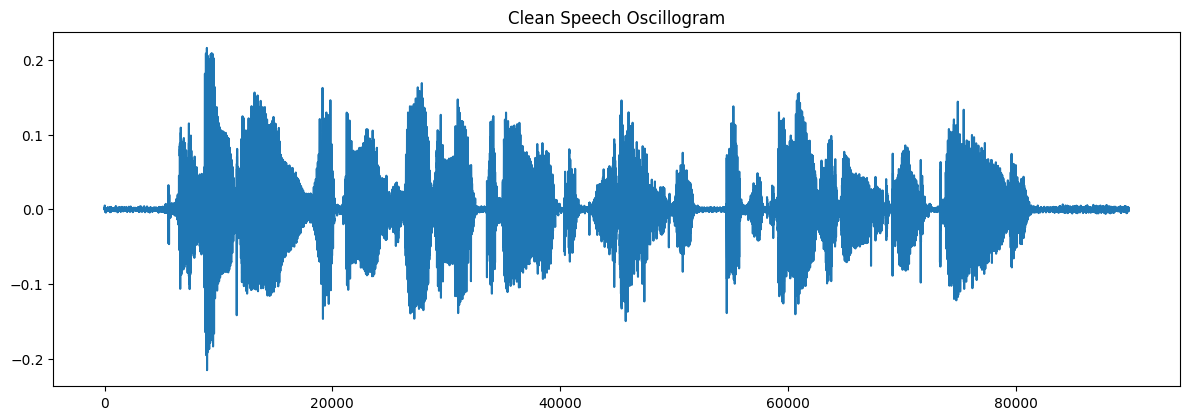

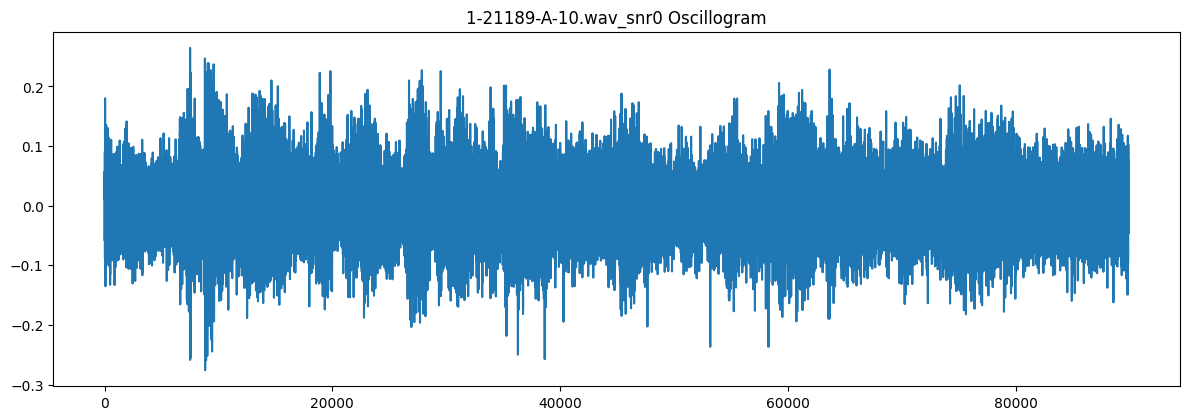

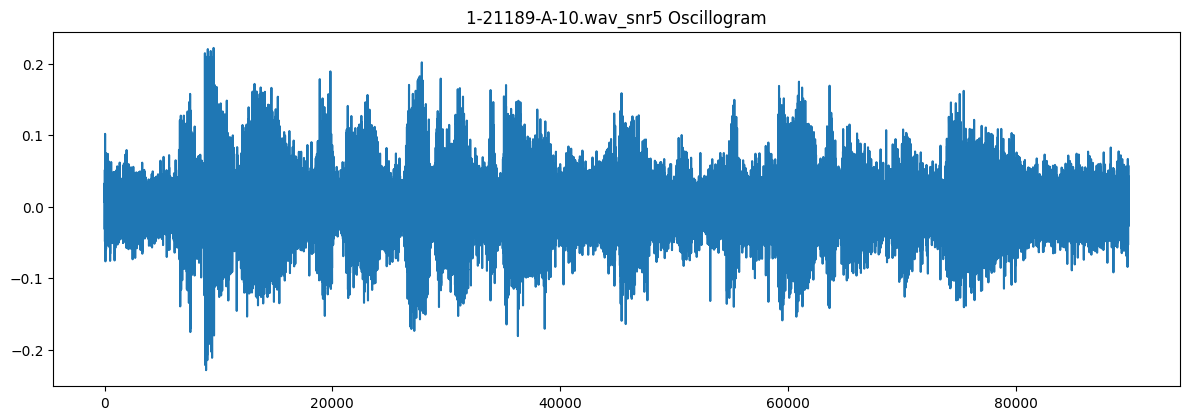

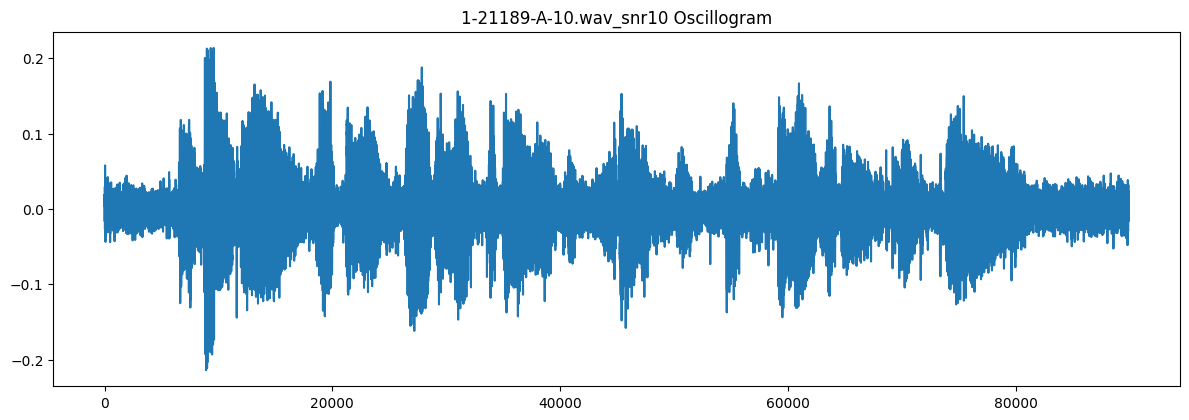

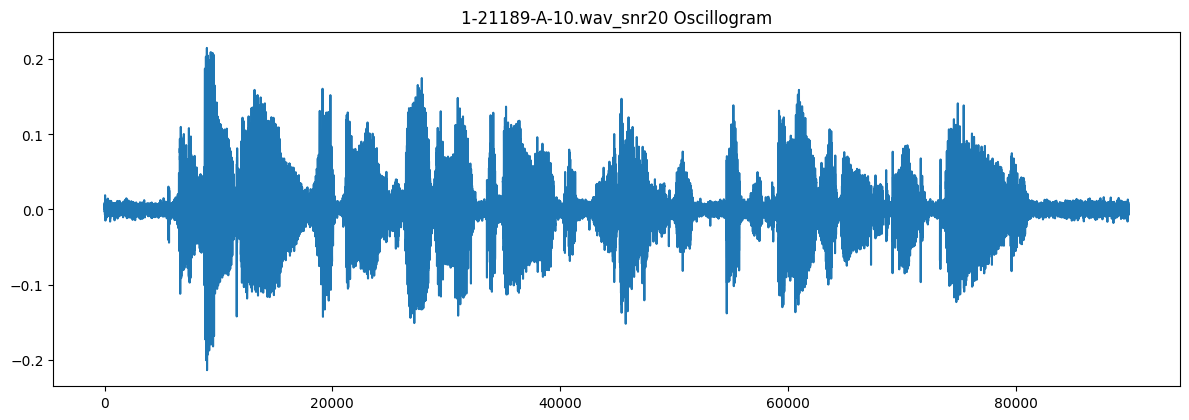

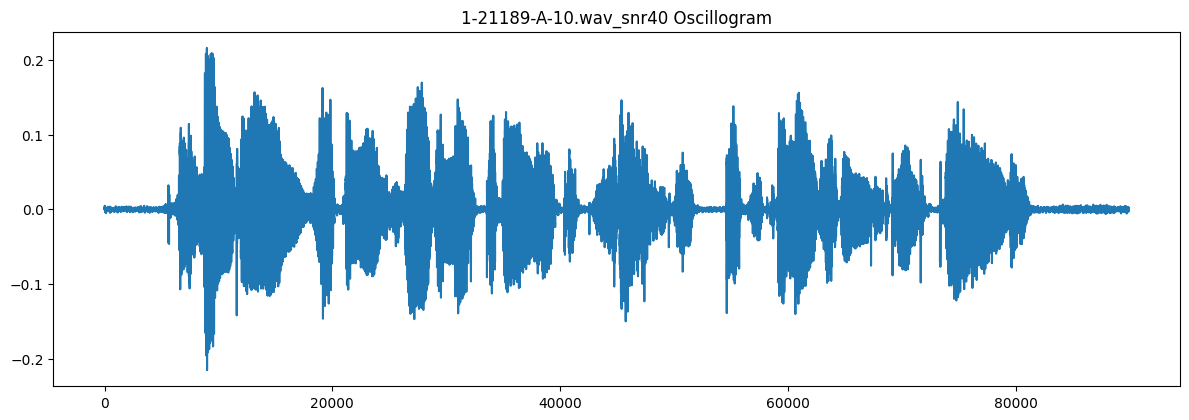

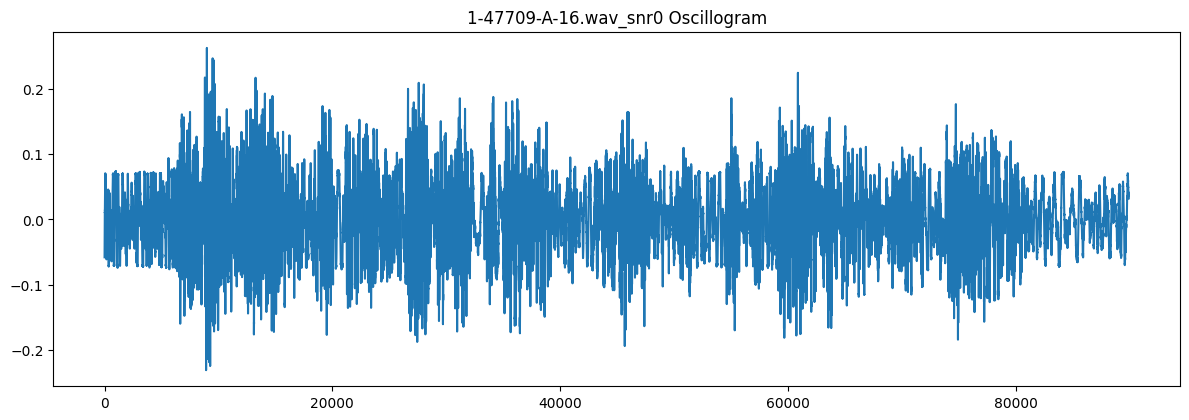

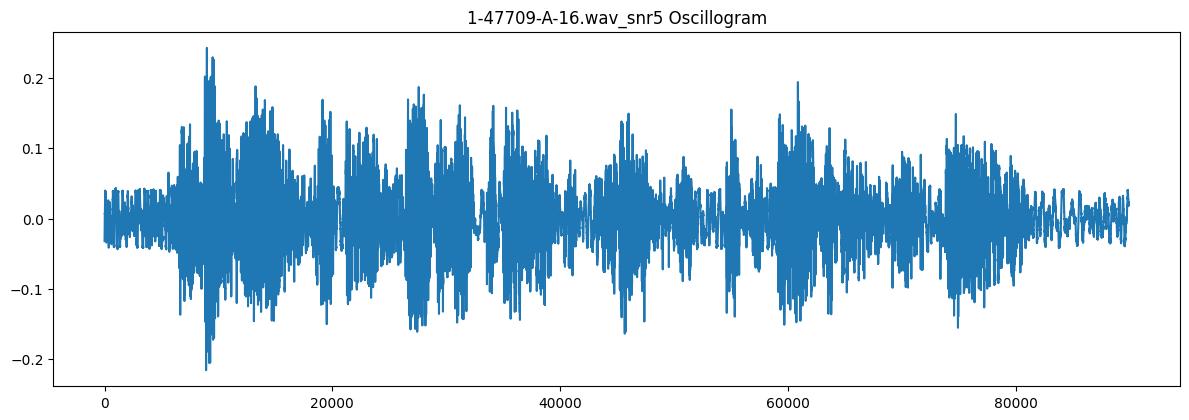

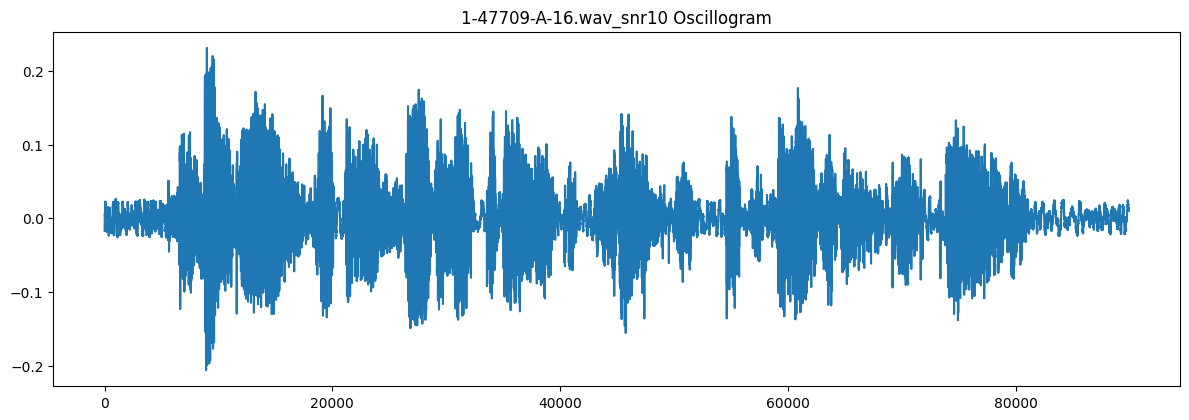

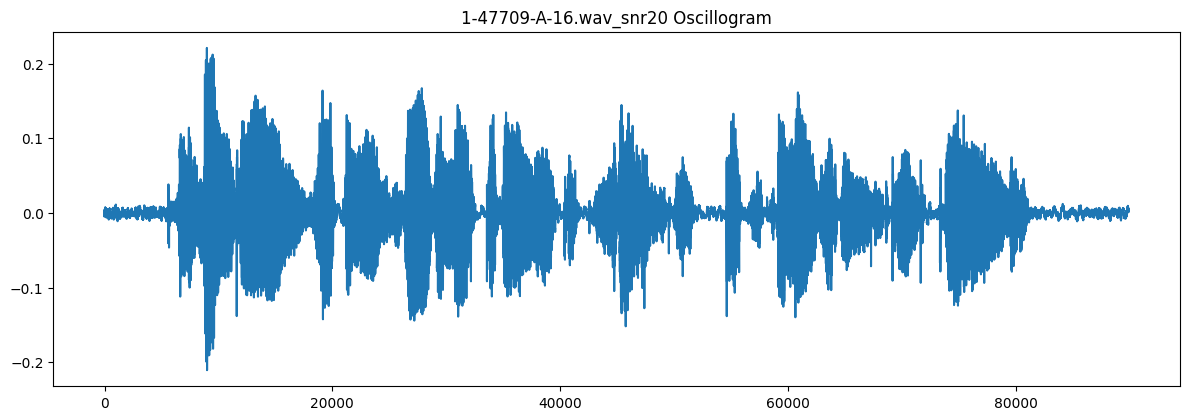

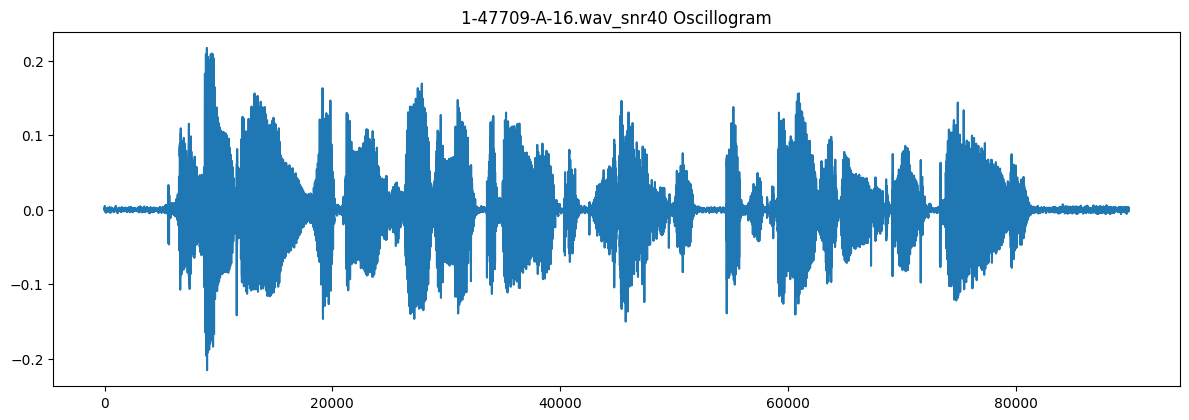

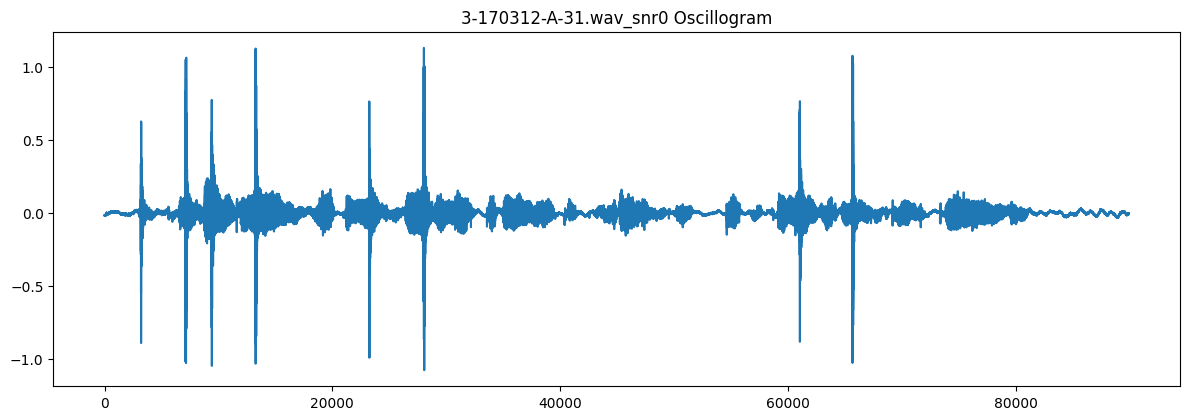

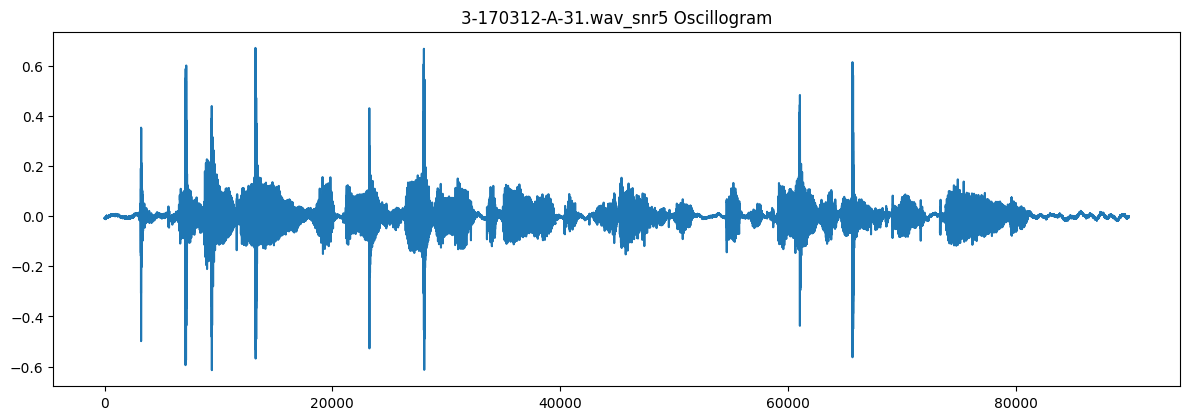

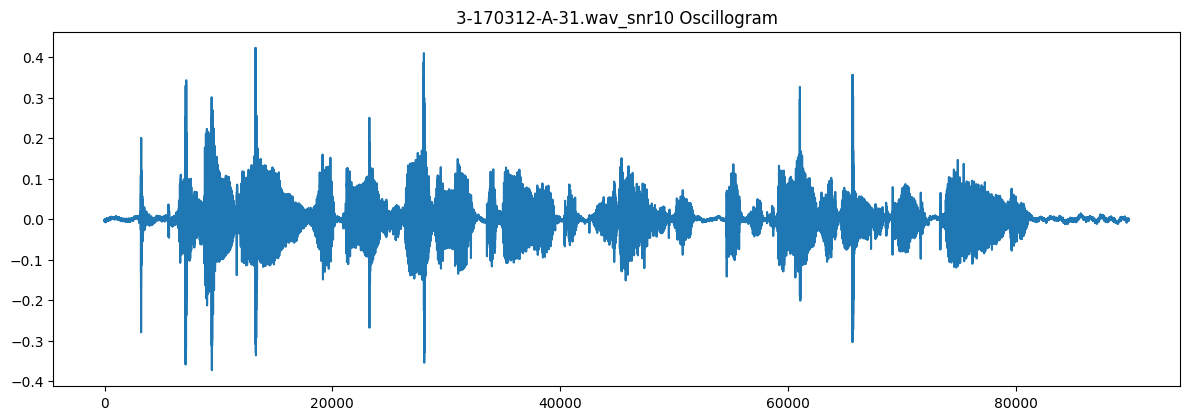

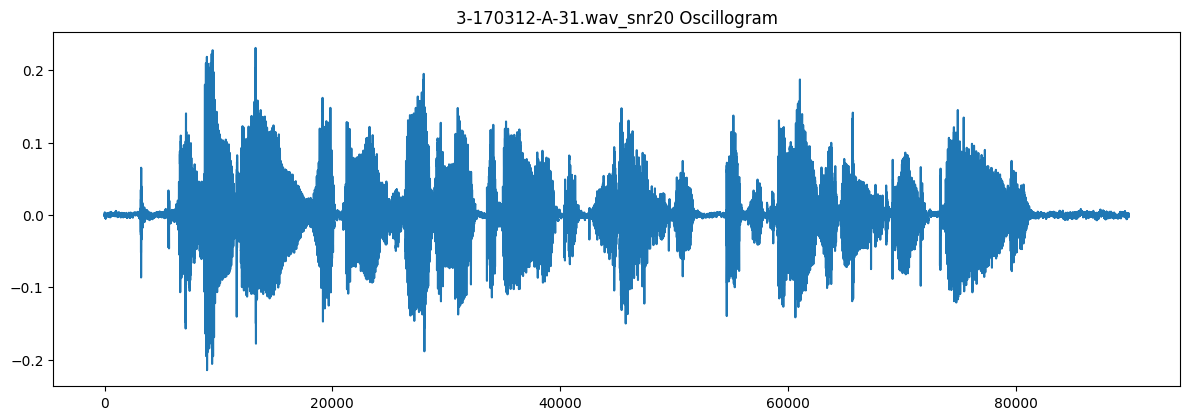

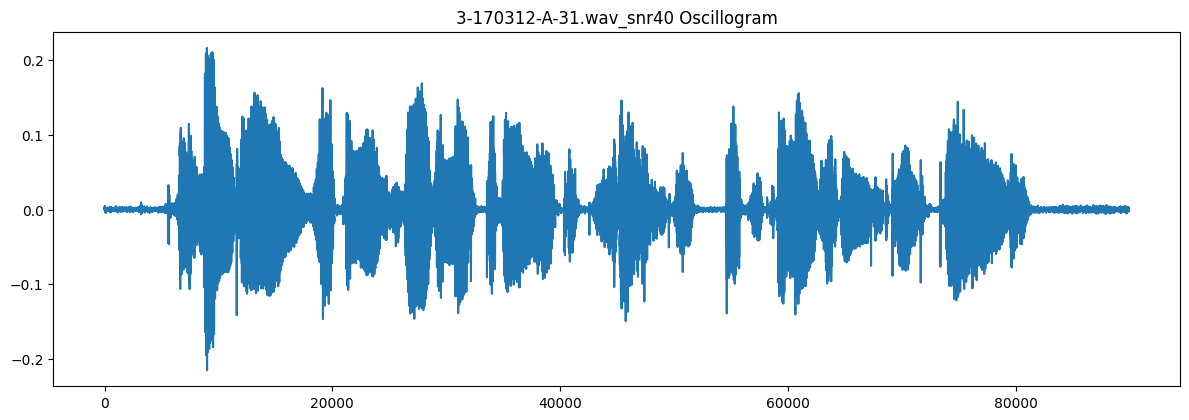

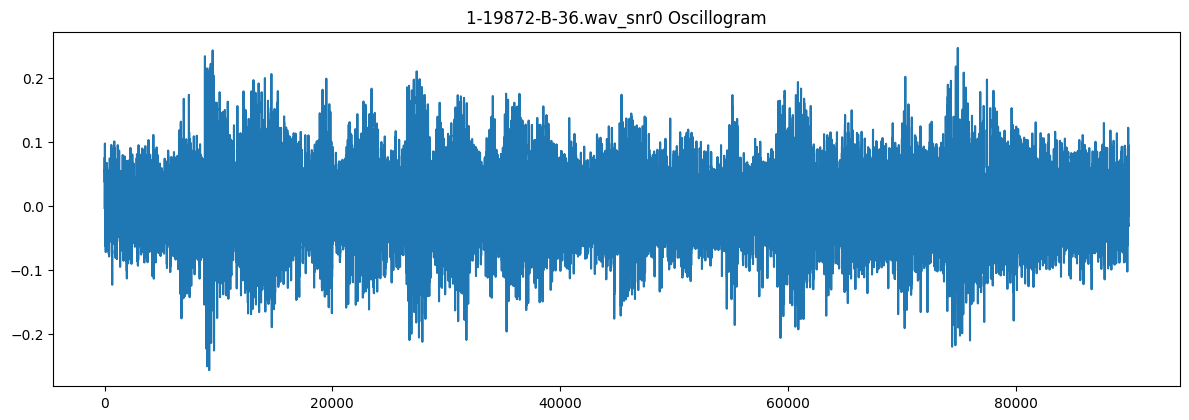

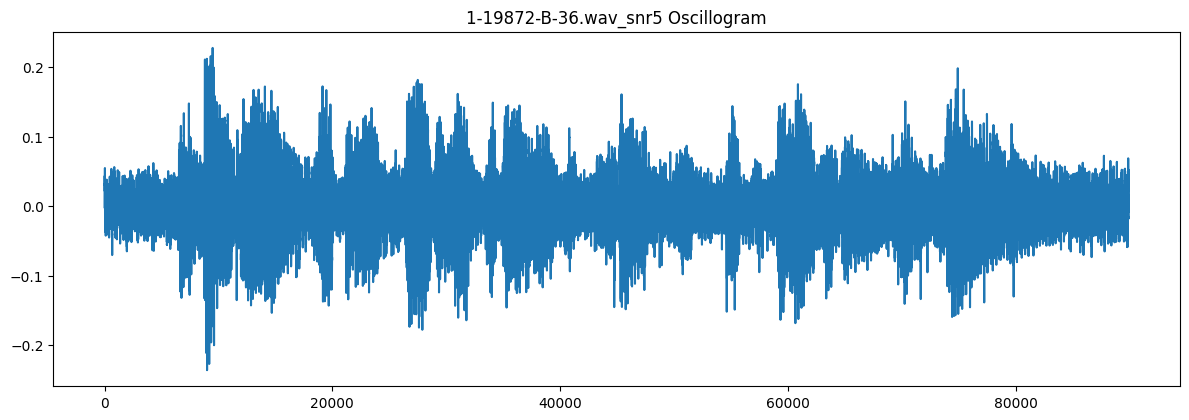

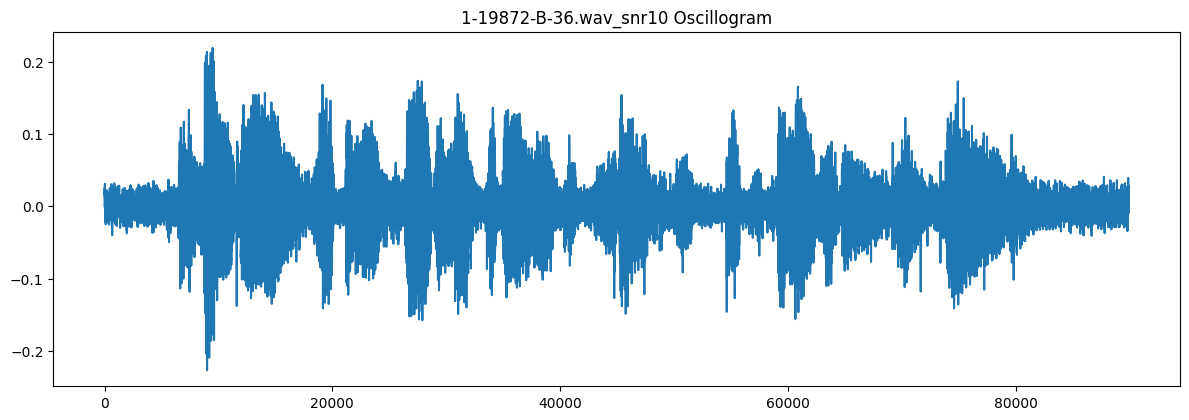

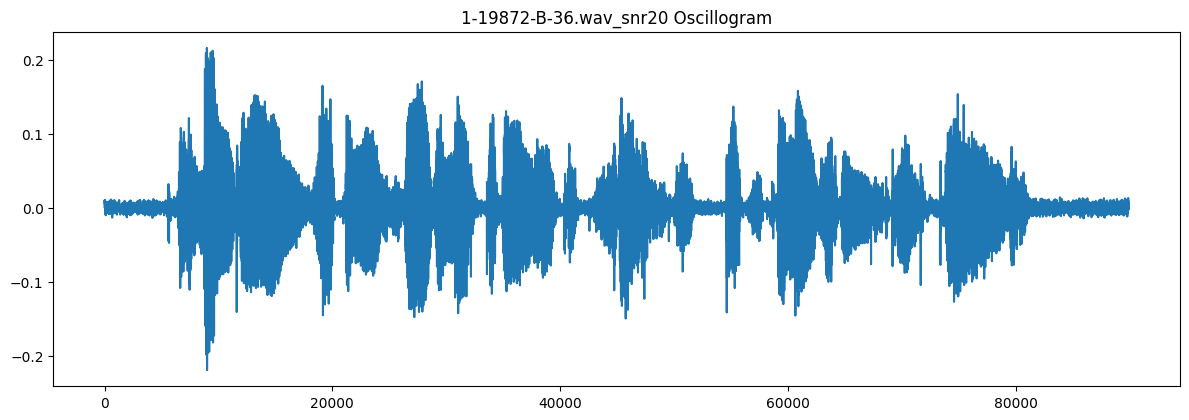

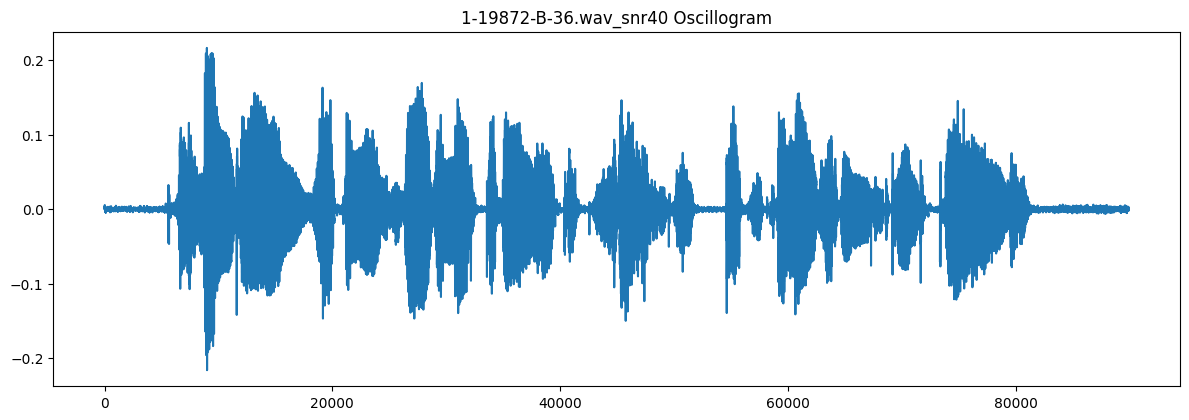

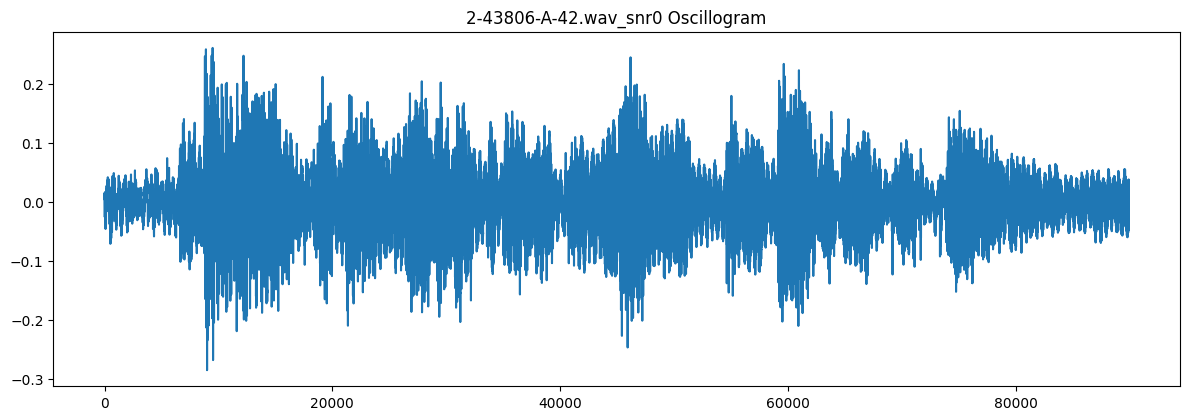

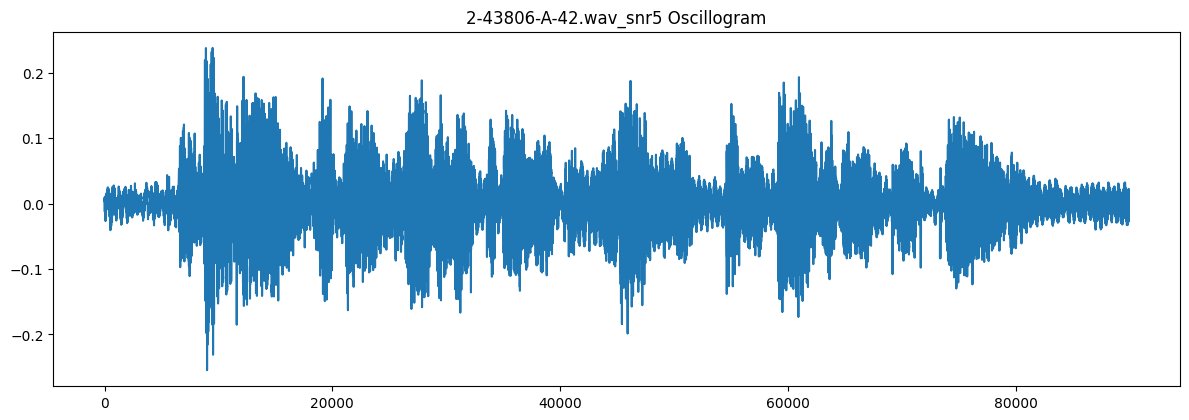

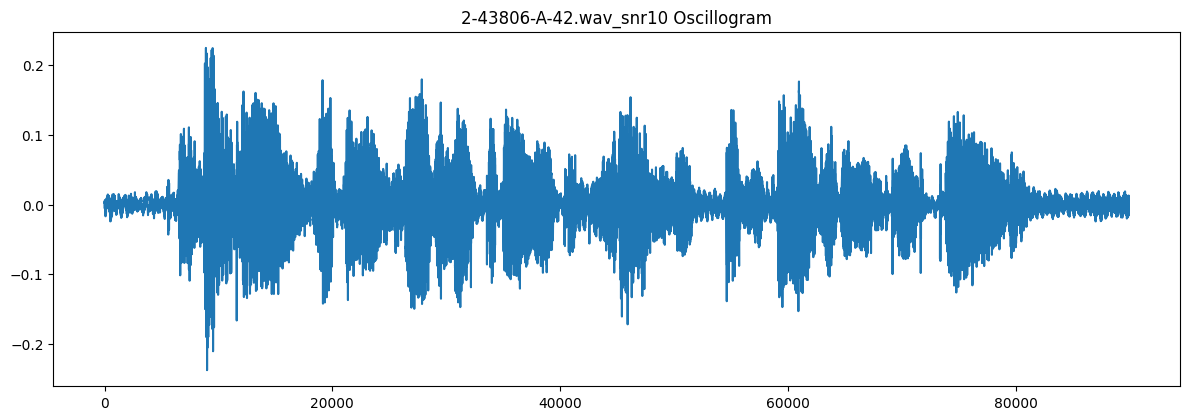

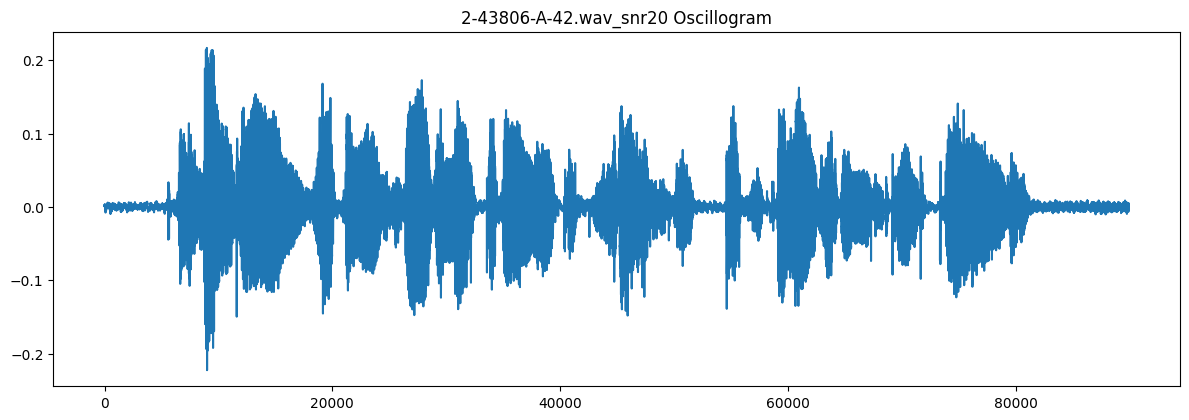

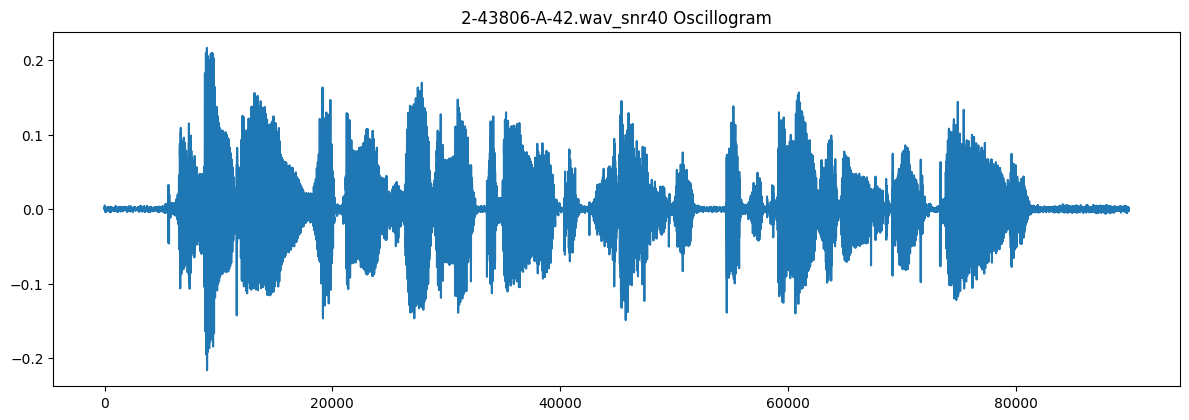

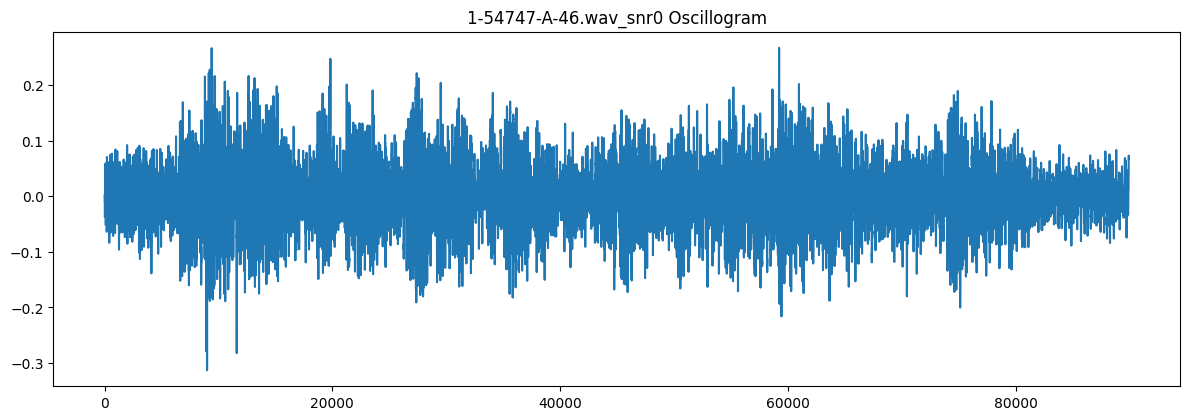

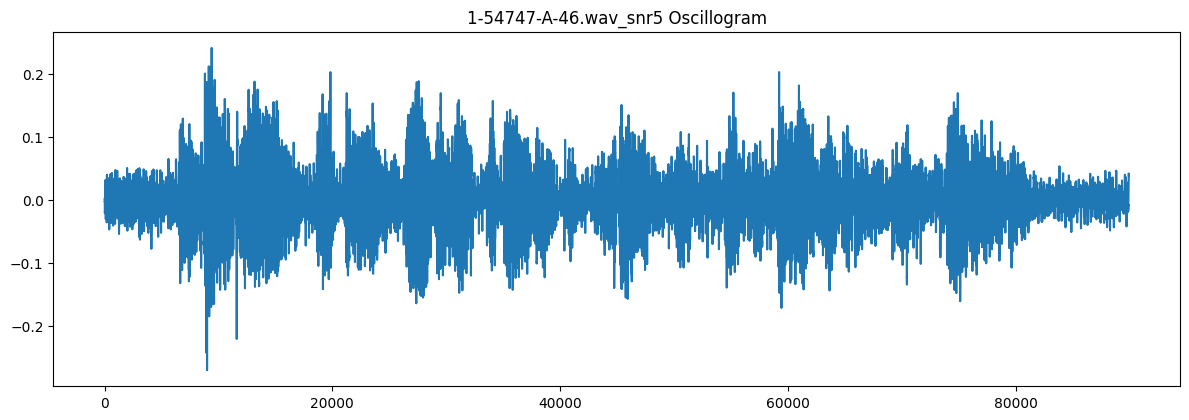

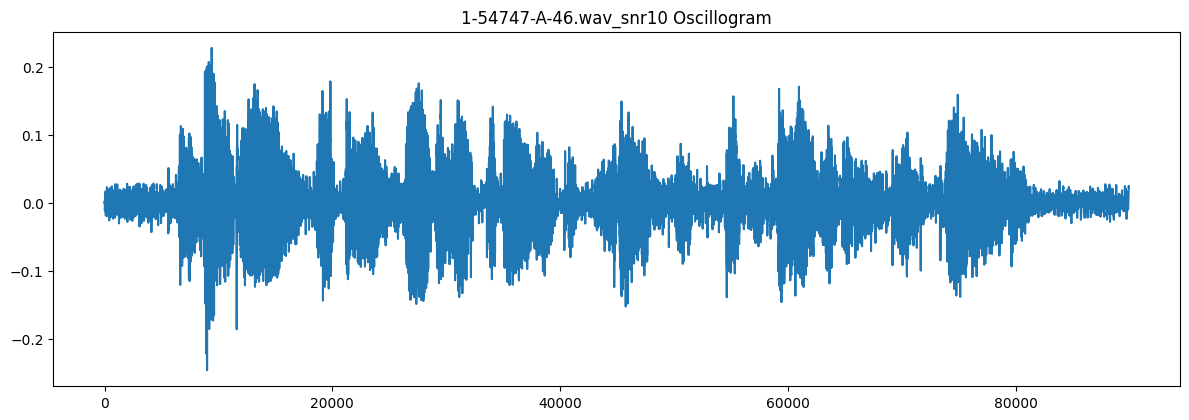

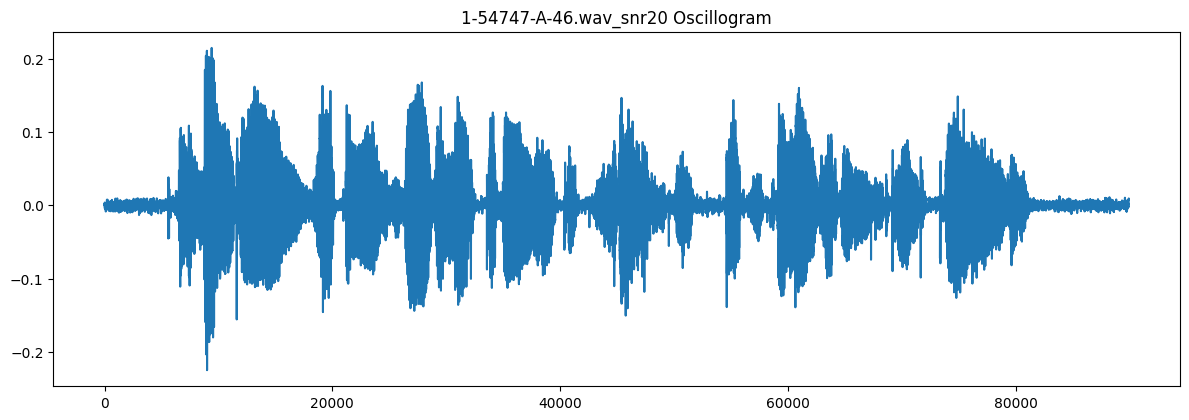

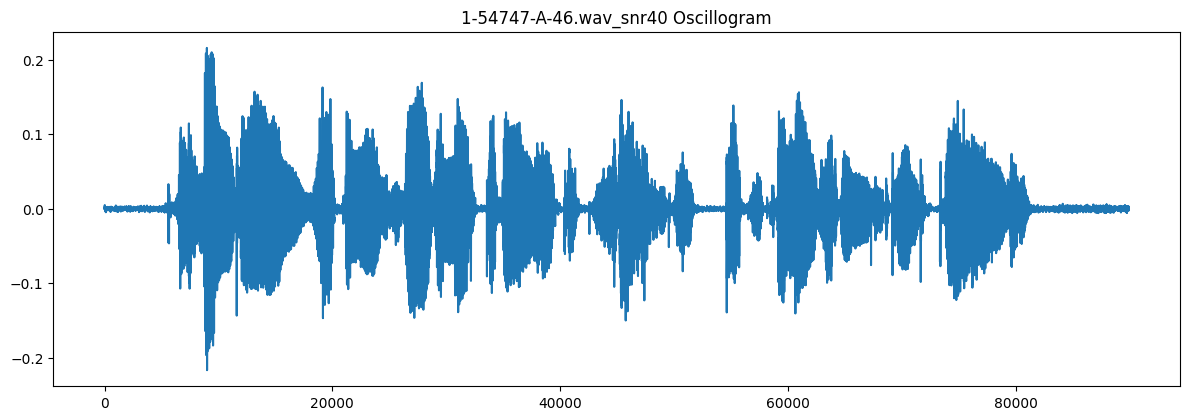

In [40]:
plot_osc_signal(speech.numpy(), sr, "Clean Speech")

for k,v in noisy_signals.items():
    plot_osc_signal(v.numpy(), sr, k)

In [41]:
plot_spec_signal(speech.numpy(), sr, "Clean Speech")

for k,v in noisy_signals.items():
    plot_spec_signal(v.numpy(), sr, k)

Output hidden; open in https://colab.research.google.com to view.

# 3 Clearing signals

Spectral Subtraction

In [10]:
def spectral_subtraction(noisy_signal, fs, n_fft=1024, win_length=1024, hop_length=256, noise_estimation_start=0, noise_estimation_end=0.1):
    """
    Аргументы:
        noisy_signal: зашумленный речевой сигнал
        fs: частота дискретизации
        n_fft: размерность БПФ
        win_length: размер окна
        hop_length: размер шага
        noise_estimation_start/end: временные отрезки для оценки

    Результат:
        denoised signal: очищенный речевой сигнал
    """
    # Вычисление STFT (кратковременное преобразование Фурье) зашумленной речи
    stft = librosa.stft(noisy_signal, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
    magnitude, phase = np.abs(stft), np.angle(stft)

    # Оценка шума, используя первые 100 мс сигнала (предполагаем, что там только шум)
    noise_frame_start = int(noise_estimation_start * fs / hop_length)
    noise_frame_end = int(noise_estimation_end * fs / hop_length)
    noise_mag = np.mean(magnitude[:, noise_frame_start:noise_frame_end], axis=1)

    # Вычитаем шум, используя маску амплитудного спектра
    magnitude_denoised = magnitude - noise_mag.reshape((-1, 1))

    # Однополупериодное выпрямление сигнала (отрицательные значения обнуляются)
    magnitude_denoised = np.clip(magnitude_denoised, a_min=0, a_max=None)

    # Восстановление сигнала, используя обратное преобразование Фурье
    stft_denoised = magnitude_denoised * np.exp(1j * phase)
    denoised_signal = librosa.istft(stft_denoised, win_length=win_length, hop_length=hop_length)

    return denoised_signal

Wiener Filter

In [11]:
def wiener_filter(noisy_signal, fs, n_fft=1024, win_length=1024, hop_length=256, noise_estimation_start=0, noise_estimation_end=0.1, smoothing_constant=0.98):
    """
    Аргументы:
        noisy_signal: зашумленный речевой сигнал
        fs: частота дискретизации
        n_fft: размерность БПФ
        win_length: размер окна
        hop_length: размер шага
        noise_estimation_start/end: временные отрезки для оценки
        smoothing_constant: константа для сглаживания оценки мощности сигнала

    Результат:
        denoised signal: очищенный речевой сигнал
    """
    # Вычисление STFT зашумленной речи
    stft = librosa.stft(noisy_signal, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
    magnitude, phase = np.abs(stft), np.angle(stft)

    # Оценка шума, используя первые 100 мс сигнала
    noise_frame_start = int(noise_estimation_start * fs / hop_length)
    noise_frame_end = int(noise_estimation_end * fs / hop_length)
    noise_mag = np.mean(np.abs(stft[:, noise_frame_start:noise_frame_end])**2, axis=1)

    # Инициализация переменных алгоритма
    num_frames = stft.shape[1]
    noise_power = noise_mag
    signal_power_est = np.zeros_like(magnitude)
    wiener_gain = np.zeros_like(magnitude)

    # Пофреймовая обработка
    for t in range(num_frames):

        # Апостериорная оценка отношения сигнал-шум (SNR)
        power = np.abs(stft[:, t])**2
        post_snr = power / noise_power

        # Априорная оценка SNR
        if t == 0:
            prior_snr = post_snr - 1
        else:
            prior_snr = smoothing_constant * (np.abs(stft[:, t-1])**2 / noise_power) + (1 - smoothing_constant) * np.clip(post_snr - 1, 0, None)

        # Коэффициент усиления фильтра Виннера
        wiener_gain[:, t] = prior_snr / (1 + prior_snr)

        # Применение коэффициента усиления
        stft[:, t] = wiener_gain[:, t] * stft[:, t]

    # Восстановление сигнала
    denoised_signal = librosa.istft(stft, win_length=win_length, hop_length=hop_length)

    return denoised_signal

RNNoise

In [16]:
# RNNoise
!rm -rf rnnoise
!git clone https://github.com/xiph/rnnoise.git
%cd rnnoise

# use stable version that includes rnnoise_data.h
!git checkout v0.4

!./autogen.sh
!./configure
!make

%cd ..

Cloning into 'rnnoise'...
remote: Enumerating objects: 907, done.
remote: Counting objects: 100% (425/425), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 907 (delta 382), reused 348 (delta 348), pack-reused 482 (from 3)
Receiving objects: 100% (907/907), 1.02 MiB | 8.78 MiB/s, done.
Resolving deltas: 100% (501/501), done.
/content/rnnoise
error: pathspec 'v0.4' did not match any file(s) known to git
--2026-03-30 13:24:45--  https://media.xiph.org/rnnoise/models/rnnoise_data-0a8755f8e2d834eff6a54714ecc7d75f9932e845df35f8b59bc52a7cfe6e8b37.tar.gz
Resolving media.xiph.org (media.xiph.org)... 54.39.18.101, 2607:5300:203:2965::
Connecting to media.xiph.org (media.xiph.org)|54.39.18.101|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58603099 (56M) [application/x-gzip]
Saving to: ‘rnnoise_data-0a8755f8e2d834eff6a54714ecc7d75f9932e845df35f8b59bc52a7cfe6e8b37.tar.gz’

rnnoise_data-0a8755 100%[===================>]  55.89M  31.8MB/s    in 1.8s   

In [12]:
import soundfile as sf
import subprocess
import os

def rnnoise_denoise(noisy, sr):

    sf.write("input.wav", noisy, sr)

    # convert to RAW 48kHz mono
    !sox input.wav -r 48000 -c 1 -b 16 -e signed-integer input.raw

    # run RNNoise
    !/content/rnnoise/examples/rnnoise_demo input.raw output.raw

    # convert RAW → WAV
    !sox -r 48000 -c 1 -b 16 -e signed-integer -t raw output.raw output.wav

    if not os.path.exists("output.wav"):
        raise RuntimeError("RNNoise failed to produce output.wav")

    clean, _ = librosa.load("output.wav", sr=sr)

    return clean

NSNet

In [18]:
# NSNet2
!git clone https://github.com/NeonGeckoCom/nsnet2-denoiser.git
%cd nsnet2-denoiser
#!pip install -r requirements.txt
!pip install .
%cd ..

Cloning into 'nsnet2-denoiser'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 85 (delta 43), reused 68 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 31.48 MiB | 26.19 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/nsnet2-denoiser
Processing /content/nsnet2-denoiser
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 94.6 MB/s eta 0:00:00
  Created wheel for nsnet2-denoiser: filename=nsnet2_denoiser-0.2.3-py3-none-any.whl size=33009135 sha256=4760404e12f37867792295b8f54bc5594941b05757cc5175fa231d692c75e41c
  Stored in directory: /root/.cache/pip/wheels/86/d1/90/e1a74cec2d5af8e2eb29e122147b93f430fd891631888d08fa
Successfully built nsnet2-denoiser
/content


In [15]:
import pathlib

file_path = "/usr/local/lib/python3.12/dist-packages/nsnet2_denoiser/enhance_onnx.py"

text = pathlib.Path(file_path).read_text()

text = text.replace(
    "sigOut = sigOut.numpy()",
    "sigOut = sigOut if isinstance(sigOut, np.ndarray) else sigOut.numpy()"
)

pathlib.Path(file_path).write_text(text)

4778

In [30]:
from nsnet2_denoiser import NSnet2Enhancer

enhancer = NSnet2Enhancer()

def nsnet_denoise(noisy, sr):
    if not isinstance(noisy, np.ndarray):
        noisy = noisy.detach().cpu().numpy()
    noisy = np.squeeze(noisy)

    # Resample to 48 kHz if needed
    if sr != 48000:
        noisy_48k = librosa.resample(noisy, orig_sr=sr, target_sr=48000)
    else:
        noisy_48k = noisy

    # Process with NSNet2
    enhanced_48k = enhancer(noisy_48k, 48000)

    # Resample back to original sr if needed
    if sr != 48000:
        enhanced = librosa.resample(enhanced_48k, orig_sr=48000, target_sr=sr)
    else:
        enhanced = enhanced_48k

    # Flatten to 1D
    enhanced = np.squeeze(enhanced)

    return enhanced

DeepFilterNet

In [25]:
# HARD reset torch stack
!pip uninstall -y torch torchaudio

# Force reinstall older versions (no cache, overwrite)
!pip install --no-cache-dir --force-reinstall \
  torch==2.2.1 \
  torchaudio==2.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 203.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 214.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 140.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 195.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 203.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 242.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 197.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 189.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 188.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 198.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 217.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [17]:
# Install Rust (required!)
!curl https://sh.rustup.rs -sSf | sh -s -- -y

# Activate Rust in current session
import os
os.environ["PATH"] += ":/root/.cargo/bin"

!pip install deepfilternet

info: downloading installer
warn: It looks like you have an existing rustup settings file at:
warn: /root/.rustup/settings.toml
warn: Rustup will install the default toolchain as specified in the settings file,
warn: instead of the one inferred from the default host triple.
info: profile set to default
info: default host triple is x86_64-unknown-linux-gnu
warn: Updating existing toolchain, profile choice will be ignored
info: syncing channel updates for stable-x86_64-unknown-linux-gnu
info: default toolchain set to stable-x86_64-unknown-linux-gnu

  stable-x86_64-unknown-linux-gnu unchanged - rustc 1.94.1 (e408947bf 2026-03-25)


Rust is installed now. Great!

To get started you may need to restart your current shell.
This would reload your PATH environment variable to include
Cargo's bin directory ($HOME/.cargo/bin).

To configure your current shell, you need to source
the corresponding env file under $HOME/.cargo.

This is usually done by running one of the following (note the leadin

In [1]:
import torchaudio
print(torchaudio.__version__)
print(hasattr(torchaudio, "backend"))

2.2.1+cu121
True


In [16]:
from df.enhance import enhance, init_df

df_model, df_state, _ = init_df()

2026-03-30 14:56:18 | INFO     | DF | Running on torch 2.2.1+cu121
2026-03-30 14:56:18 | INFO     | DF | Running on host 3c656e8e4f0f
2026-03-30 14:56:18 | INFO     | DF | Loading model settings of DeepFilterNet3
2026-03-30 14:56:18 | INFO     | DF | Using DeepFilterNet3 model at /root/.cache/DeepFilterNet/DeepFilterNet3
2026-03-30 14:56:18 | INFO     | DF | Initializing model `deepfilternet3`
2026-03-30 14:56:18 | INFO     | DF | Found checkpoint /root/.cache/DeepFilterNet/DeepFilterNet3/checkpoints/model_120.ckpt.best with epoch 120
2026-03-30 14:56:18 | INFO     | DF | Running on device cpu
2026-03-30 14:56:18 | INFO     | DF | Model loaded


/usr/local/lib/python3.12/dist-packages/df/io.py:9: UserWarning: `torchaudio.backend.common.AudioMetaData` has been moved to `torchaudio.AudioMetaData`. Please update the import path.
  from torchaudio.backend.common import AudioMetaData


In [23]:
def deepfilternet_denoise(audio_np, sr):

    if sr != 48000:
        audio_np = librosa.resample(audio_np, orig_sr=sr, target_sr=48000)

    audio_tensor = torch.from_numpy(audio_np).float()

    # Add batch dimension if needed
    if audio_tensor.dim() == 1:
        audio_tensor = audio_tensor.unsqueeze(0)

    enhanced = enhance(df_model, df_state, audio_tensor)

    enhanced = enhanced.squeeze().detach().cpu().numpy()

    return enhanced, 48000

Run Denoising

In [63]:
def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    return x.detach().cpu().numpy()

In [31]:
denoised_results = {}

for key, noisy in noisy_signals.items():

    noisy_np = noisy.squeeze().numpy()

    denoised_results[key] = {}

    denoised_results[key]["spectral"] = spectral_subtraction(noisy_np, sr)

    denoised_results[key]["wiener"] = wiener_filter(noisy_np, sr)

    denoised_results[key]["rnnoise"] = rnnoise_denoise(noisy_np, sr)

    denoised_results[key]["nsnet"] = nsnet_denoise(noisy_np, sr)

    enhanced, df_sr = deepfilternet_denoise(noisy_np, sr)
    enhanced = librosa.resample(enhanced, orig_sr=df_sr, target_sr=sr)

    denoised_results[key]["deepfilternet"] = enhanced

sox WARN rate: rate clipped 32 samples; decrease volume?
sox WARN dither: dither clipped 28 samples; decrease volume?


Display cleaned signals

In [32]:
for key in denoised_results:
    for method, signal in denoised_results[key].items():
      title = key + "_" + method
      print(title)
      display(Audio(signal, rate=sr))

Output hidden; open in https://colab.research.google.com to view.

In [42]:
for key in denoised_results:
    for method, signal in denoised_results[key].items():

        title = key + "_" + method
        plot_osc_signal(signal, sr, title)

Output hidden; open in https://colab.research.google.com to view.

In [44]:
for key in denoised_results:
    for method, signal in denoised_results[key].items():

        title = key + "_" + method
        plot_spec_signal(signal, sr, title)

Output hidden; open in https://colab.research.google.com to view.

# 4 PESQ

In [33]:
scores = {}

for key in denoised_results:

    scores[key] = {}

    for method, signal in denoised_results[key].items():

        ref = speech.numpy()

        # Flatten to 1D
        ref = np.squeeze(ref)
        deg = np.squeeze(signal)

        min_len = min(len(ref), len(deg))
        ref = ref[:min_len]
        deg = deg[:min_len]

        # PESQ requires 16 kHz
        ref = librosa.resample(ref, orig_sr=sr, target_sr=16000)
        deg = librosa.resample(deg, orig_sr=sr, target_sr=16000)

        score = pesq(16000, ref, deg, 'wb')

        scores[key][method] = round(score, 3)

pprint.pprint(scores)

{'1-19872-B-36.wav_snr0': {'deepfilternet': 1.33,
                           'nsnet': 1.207,
                           'rnnoise': 1.091,
                           'spectral': 1.13,
                           'wiener': 1.111},
 '1-19872-B-36.wav_snr10': {'deepfilternet': 1.684,
                            'nsnet': 1.491,
                            'rnnoise': 1.318,
                            'spectral': 1.742,
                            'wiener': 1.479},
 '1-19872-B-36.wav_snr20': {'deepfilternet': 2.276,
                            'nsnet': 1.84,
                            'rnnoise': 1.697,
                            'spectral': 2.745,
                            'wiener': 2.198},
 '1-19872-B-36.wav_snr40': {'deepfilternet': 3.504,
                            'nsnet': 2.046,
                            'rnnoise': 2.134,
                            'spectral': 4.144,
                            'wiener': 3.037},
 '1-19872-B-36.wav_snr5': {'deepfilternet': 1.478,
                 

In [34]:
with open("pesq_scores.json", "w") as f:
    json.dump(scores, f, indent=4)

AVG PESQ

In [35]:
from collections import defaultdict

method_scores = defaultdict(list)

# collect scores by method
for key in scores:
    for method, value in scores[key].items():
        method_scores[method].append(value)

# compute averages
avg_scores = {}

for method, values in method_scores.items():
    avg_scores[method] = round(sum(values) / len(values), 3)

# display results
print("Average PESQ per method:\n")

for method, avg in avg_scores.items():
    print(f"{method}: {avg}")

Average PESQ per method:

spectral: 2.183
wiener: 1.83
rnnoise: 1.576
nsnet: 1.676
deepfilternet: 2.294


AVG PESQ table

In [36]:
# store scores
table = defaultdict(lambda: defaultdict(list))

for key, methods in scores.items():

    # extract SNR from key like "..._snr10"
    snr = int(key.split("_")[-1].replace("snr", ""))

    for method, value in methods.items():
        table[method][snr].append(value)

# compute averages
avg_table = {}

for method in table:

    avg_table[method] = {}

    for snr in snr_levels:

        values = table[method][snr]

        if values:
            avg_table[method][snr] = round(np.mean(values), 3)
        else:
            avg_table[method][snr] = None

# convert to table
df = pd.DataFrame(avg_table).T
df = df[snr_levels]

df.index.name = "Method"
df.columns = ["0 dB", "5 dB", "10 dB", "20 dB", "40 dB"]

display(df)

,0 dB,5 dB,10 dB,20 dB,40 dB
Method,,,,,
spectral,1.148,1.369,1.693,2.607,4.098
wiener,1.123,1.295,1.535,2.118,3.078
rnnoise,1.202,1.311,1.464,1.788,2.114
nsnet,1.374,1.509,1.643,1.837,2.018
deepfilternet,1.586,1.817,2.053,2.576,3.439
